# Healthcare Analytics EDA with **Python**


# Data Loading, Inspection and Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [2]:
liverdata = pd.read_excel('/content/drive/MyDrive/Projects/Liver Screening Data Analysis/liver_screening_dataset.xlsx')

In [3]:
df = liverdata.copy()

In [4]:
df.head()

,Age,Gender,Total Bilirubin,Direct Bilirubin,ALP,ALT,AST,Total Protiens,Albumin,A/G Ratio,Dataset
0,65,Female,0.7,0.1,187.0,16,18.0,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699.0,64,100.0,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490.0,60,68.0,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182.0,14,20.0,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195.0,27,59.0,7.3,2.4,0.40,1


In [5]:
df.shape

(583, 11)

This dataset contains deranged values from a liver function tests conducted for 583 patients. It contains 10 relevant columns i.e., Age, Gender, Total Bilirubin, Direct Bilirubin, ALP, ALT, AST values, Total Proteins, ALbumin, and A/G Ratio


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               583 non-null    int64  
 1   Gender            583 non-null    object 
 2   Total Bilirubin   583 non-null    float64
 3   Direct Bilirubin  582 non-null    float64
 4   ALP               579 non-null    float64
 5   ALT               583 non-null    int64  
 6   AST               582 non-null    float64
 7   Total Protiens    582 non-null    float64
 8   Albumin           583 non-null    float64
 9   A/G Ratio         578 non-null    float64
 10  Dataset           583 non-null    int64  
dtypes: float64(7), int64(3), object(1)
memory usage: 50.2+ KB


In [7]:
df.isnull().sum()

,0
Age,0
Gender,0
Total Bilirubin,0
Direct Bilirubin,1
ALP,4
ALT,0
AST,1
Total Protiens,1
Albumin,0
A/G Ratio,5


In [8]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

#transform string to nubmers by encoding (replacing options with 0s and 1s)
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(liverdata['Gender'])


imputer = KNNImputer(n_neighbors=5)
df_imputed = imputer.fit_transform(df)
df_imputed = pd.DataFrame(df_imputed, columns=df.columns)

In [9]:
df_liver = df_imputed.copy()

In [10]:
df_liver.duplicated().sum()

np.int64(13)

In [11]:
df_liver = df_liver.drop_duplicates()
df_liver.shape

(570, 11)

In [12]:
df_liver.head()

,Age,Gender,Total Bilirubin,Direct Bilirubin,ALP,ALT,AST,Total Protiens,Albumin,A/G Ratio,Dataset
0,65.0,0.0,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1.0
1,62.0,1.0,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1.0
2,62.0,1.0,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1.0
3,58.0,1.0,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1.0
4,72.0,1.0,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1.0


In [13]:
df_liver = df.rename(columns={'Total Protiens': 'Total Proteins'})

In [14]:
df_liver = df_liver.drop('Dataset', axis=1)

In [15]:
#returning columns to original data types
df_liver['Age'] = df['Age'].astype(int)
df_liver['Gender'] = df['Gender'].astype('category')
df_liver['Gender'] = df['Gender'].replace({0.0: 'Female', 1.0: 'Male'})

df_liver.head()

,Age,Gender,Total Bilirubin,Direct Bilirubin,ALP,ALT,AST,Total Proteins,Albumin,A/G Ratio
0,65,Female,0.7,0.1,187.0,16,18.0,6.8,3.3,0.90
1,62,Male,10.9,5.5,699.0,64,100.0,7.5,3.2,0.74
2,62,Male,7.3,4.1,490.0,60,68.0,7.0,3.3,0.89
3,58,Male,1.0,0.4,182.0,14,20.0,6.8,3.4,1.00
4,72,Male,3.9,2.0,195.0,27,59.0,7.3,2.4,0.40


**Issues Identified and Corrected**

1. missing values in several columns. They were replaced using KNN imputation.

2. 13 duplictated rows were found and removed.

3. An irrelevant column was removed from the data

4. Column data types were corrected

5. Outliers were left untouched





# Univariate Analysis

In [16]:
df_liver.shape

(583, 10)

In [17]:
df_liver.head()

,Age,Gender,Total Bilirubin,Direct Bilirubin,ALP,ALT,AST,Total Proteins,Albumin,A/G Ratio
0,65,Female,0.7,0.1,187.0,16,18.0,6.8,3.3,0.90
1,62,Male,10.9,5.5,699.0,64,100.0,7.5,3.2,0.74
2,62,Male,7.3,4.1,490.0,60,68.0,7.0,3.3,0.89
3,58,Male,1.0,0.4,182.0,14,20.0,6.8,3.4,1.00
4,72,Male,3.9,2.0,195.0,27,59.0,7.3,2.4,0.40


In [18]:
df_liver.describe()

,Age,Total Bilirubin,Direct Bilirubin,ALP,ALT,AST,Total Proteins,Albumin,A/G Ratio
count,583.000000,583.000000,582.000000,579.000000,583.000000,582.000000,582.000000,583.000000,578.000000
mean,44.746141,3.298799,1.488316,290.948187,80.713551,109.673540,6.484192,3.141852,0.946782
std,16.189833,6.209522,2.810406,243.706658,182.620356,289.110208,1.086115,0.795519,0.319797
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000


In [19]:
mode_age = df_liver['Age'].mode()[0]
mode_count = df_liver['Age'].value_counts()[mode_age]

print(f"Mode Age: {mode_age}, Count: {mode_count}")

Mode Age: 60, Count: 34


In [20]:
#calculating most occuring age group
bins = [1, 12, 19, 39, 59, float('inf')]
labels = ['Infants (1 - 12)', 'Adolescents (13 - 19)', 'Adults (20 - 39)', 'Middle-aged (40 - 59)', 'Seniors (60+)']

df_liver['Age Group'] = pd.cut(df_liver['Age'], bins=bins, labels=labels, right=False)

mode_age_group = df_liver['Age Group'].mode()
mode_age_group

,Age Group
0,Middle-aged (40 - 59)


In [21]:
df_liver.describe(include=['category'])

,Age Group
count,583
unique,5
top,Middle-aged (40 - 59)
freq,231


In [22]:
df_liver.columns

Index(['Age', 'Gender', 'Total Bilirubin', 'Direct Bilirubin', 'ALP', 'ALT',
       'AST', 'Total Proteins', 'Albumin', 'A/G Ratio', 'Age Group'],
      dtype='object')

In [23]:
# Creating an AST/ALT Ratio column
df_liver['AST/ALT Ratio'] = df_liver['AST'] / df_liver['ALT']

**Visualizing Columns to Identify Distributions**

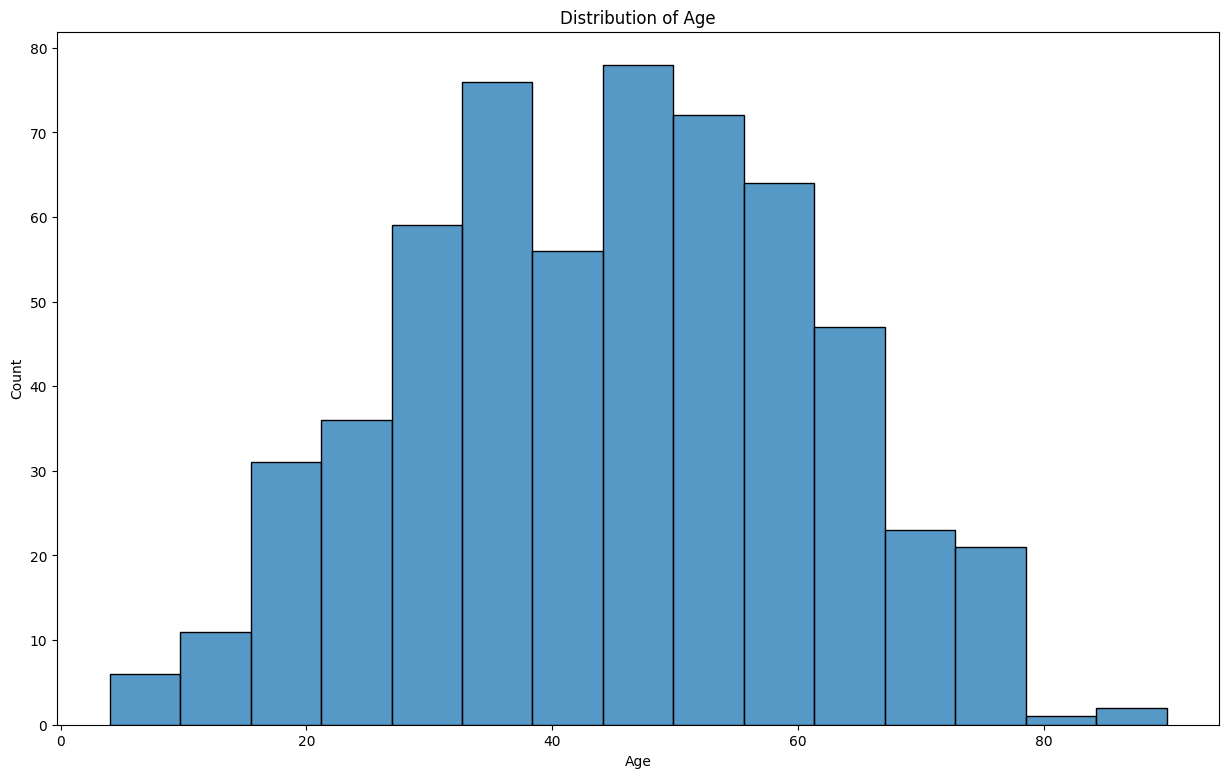

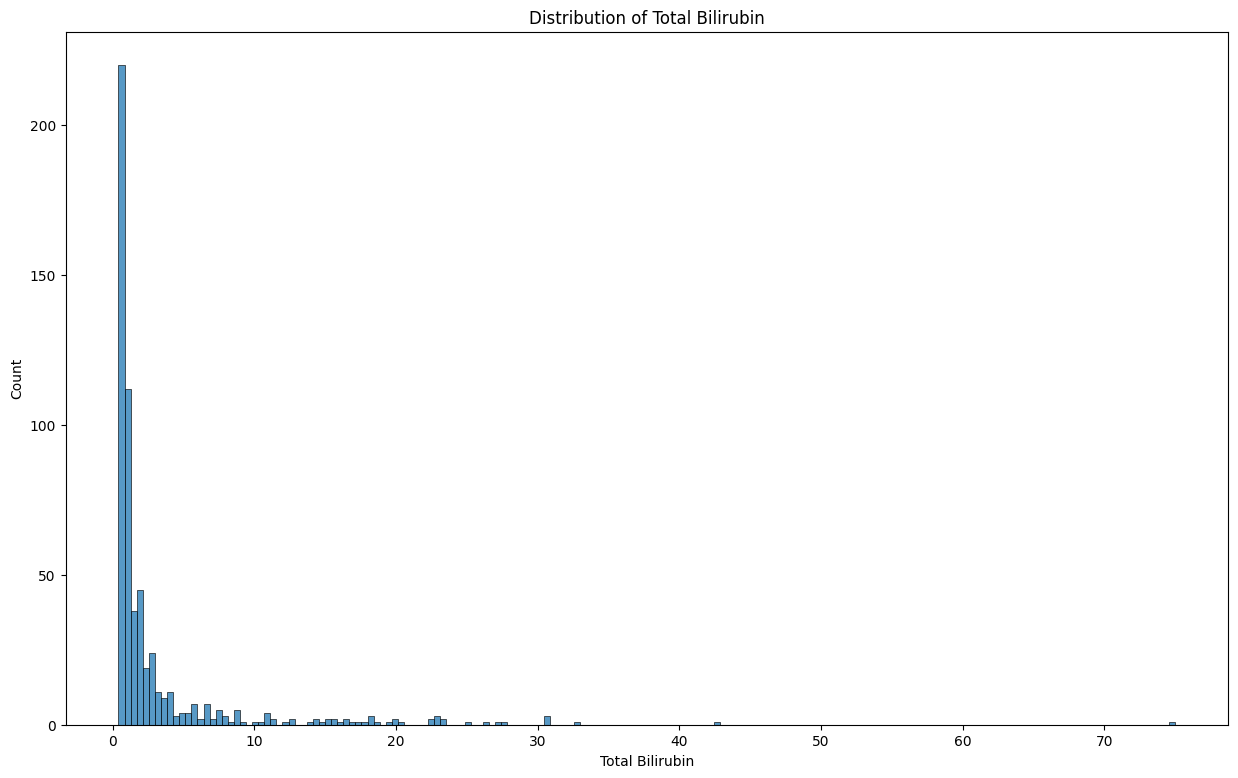

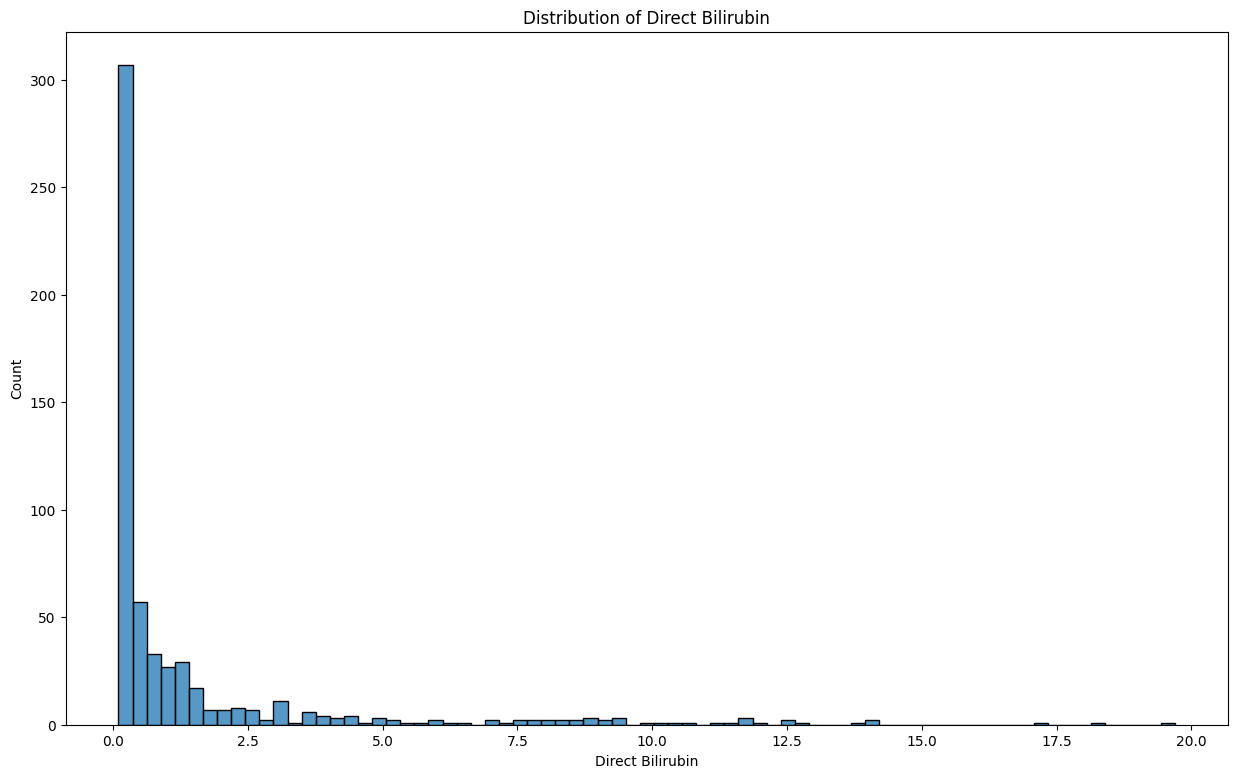

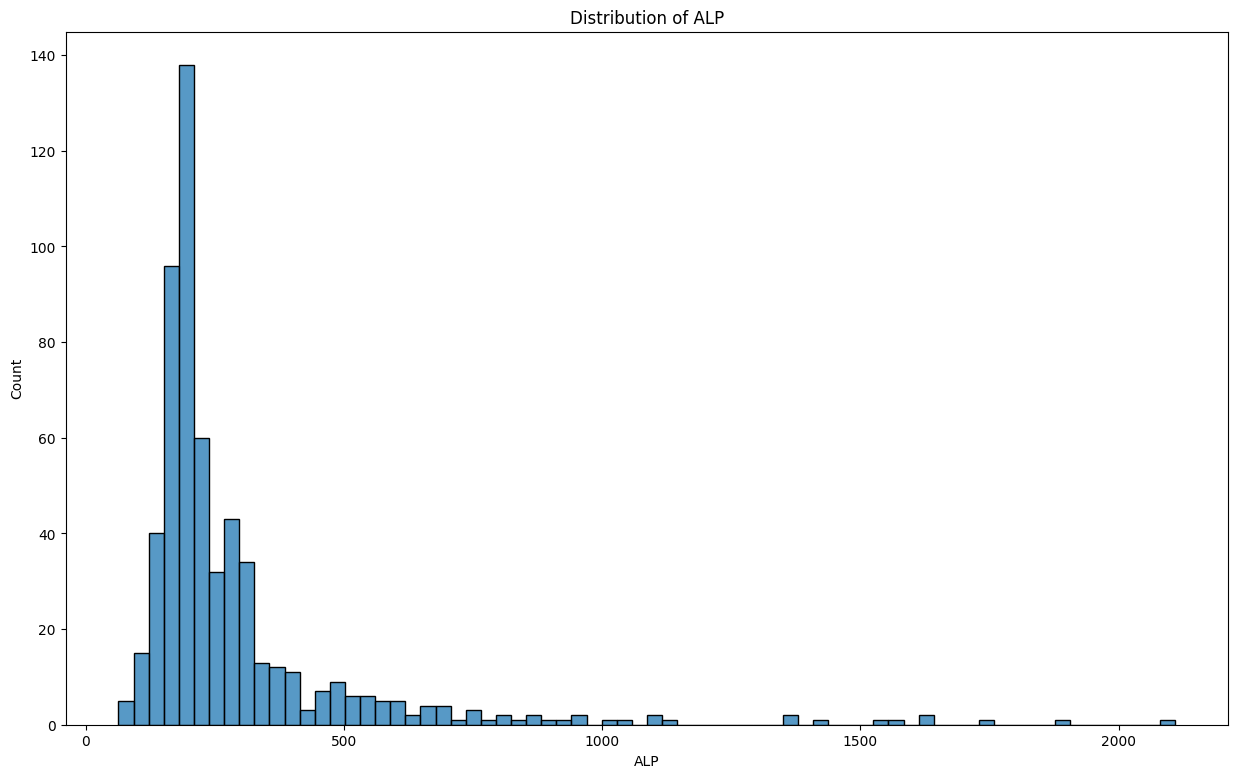

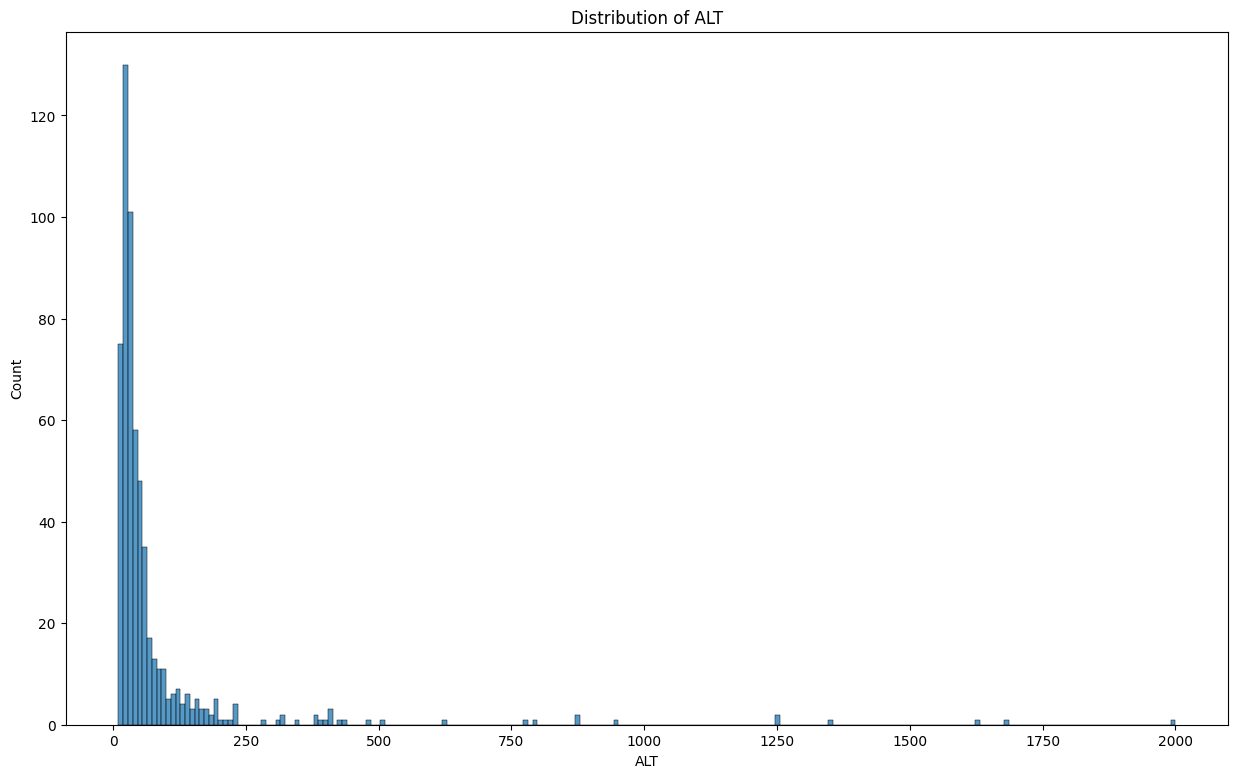

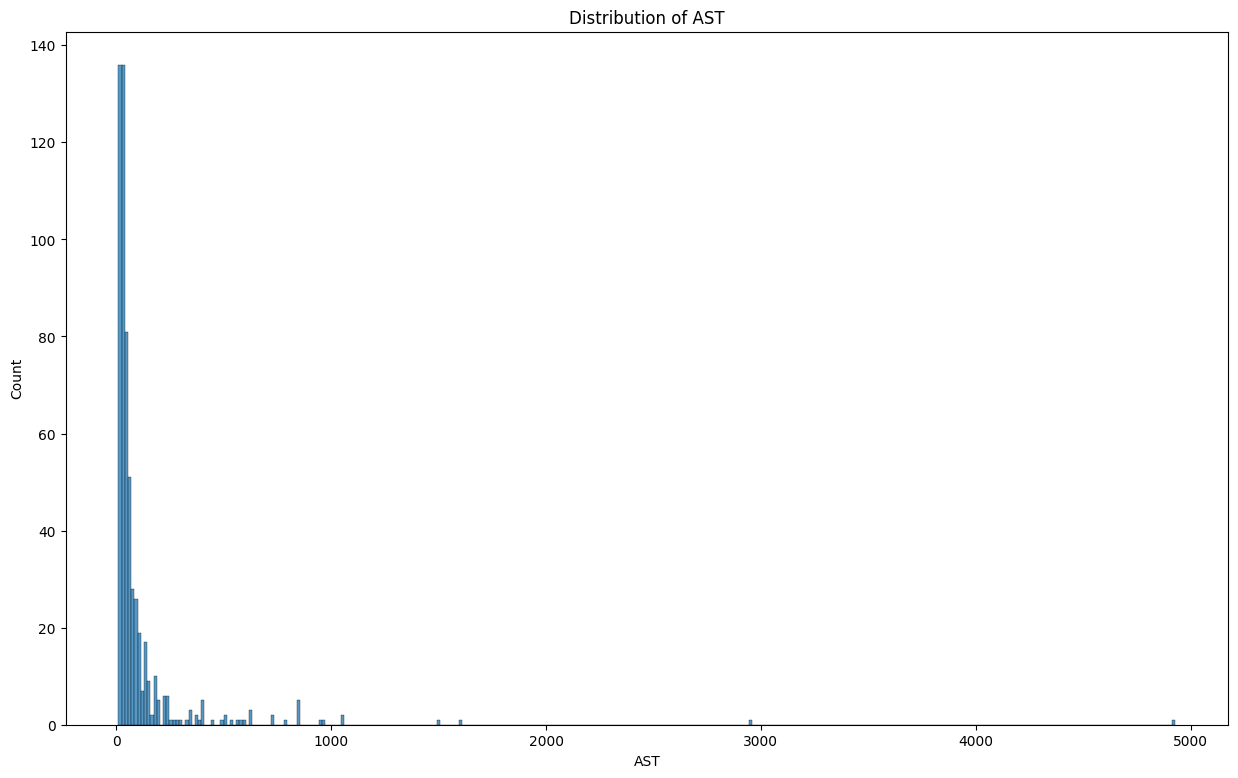

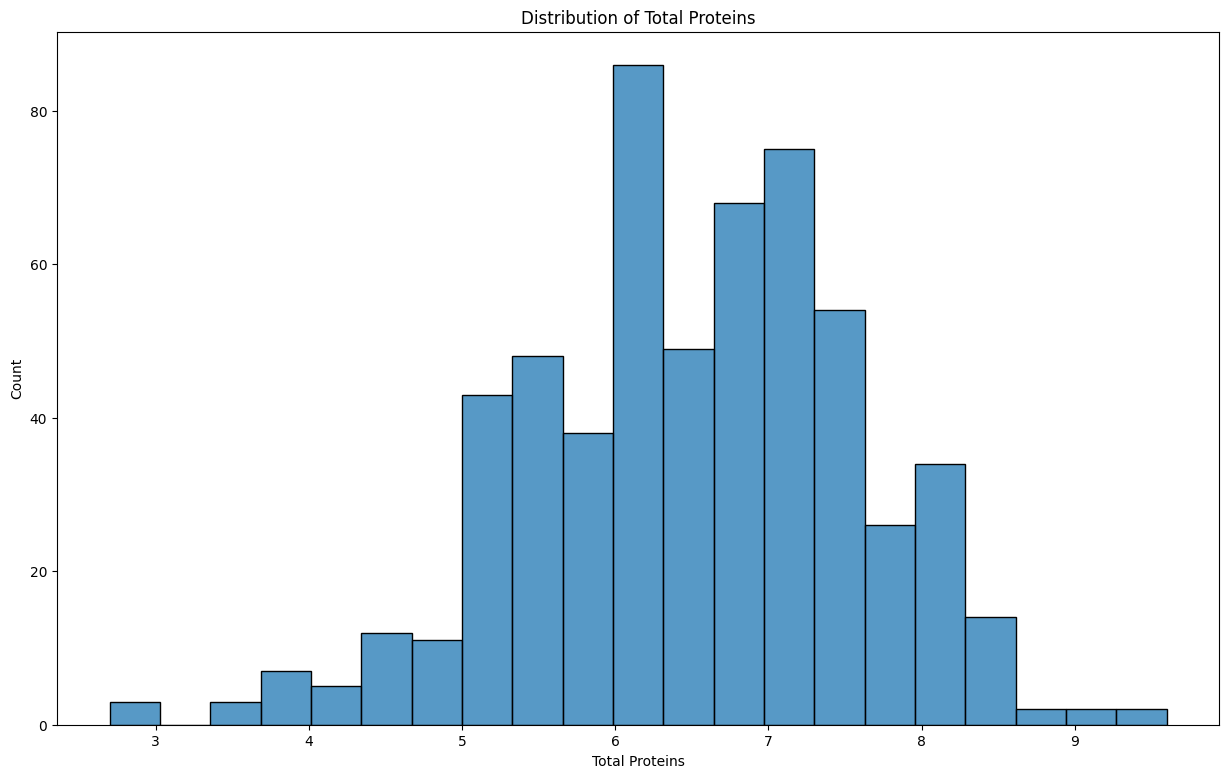

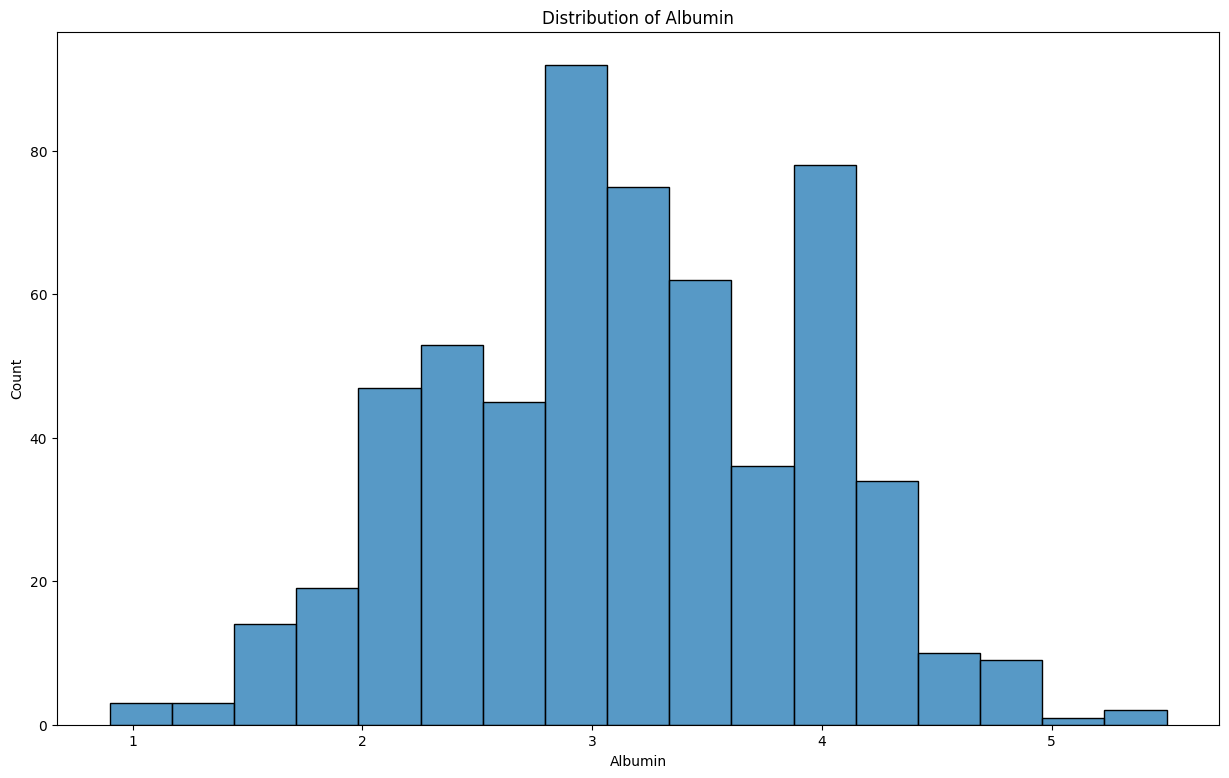

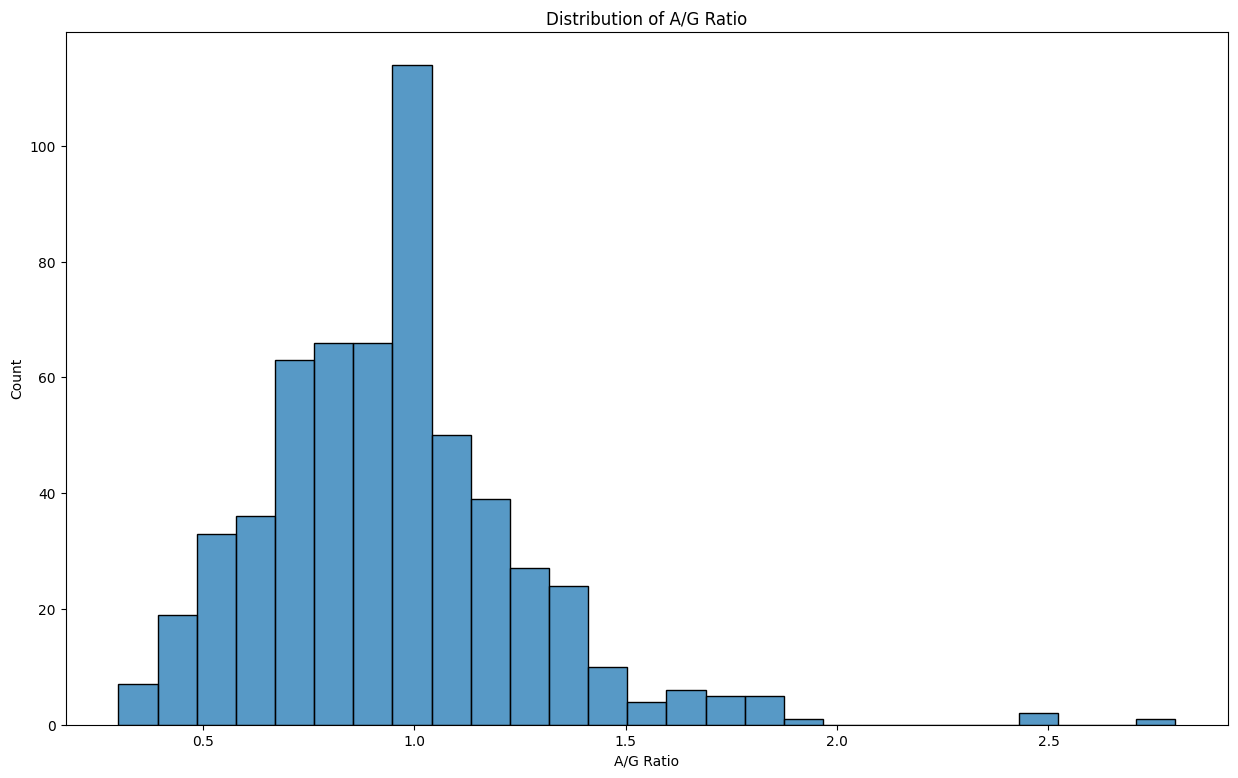

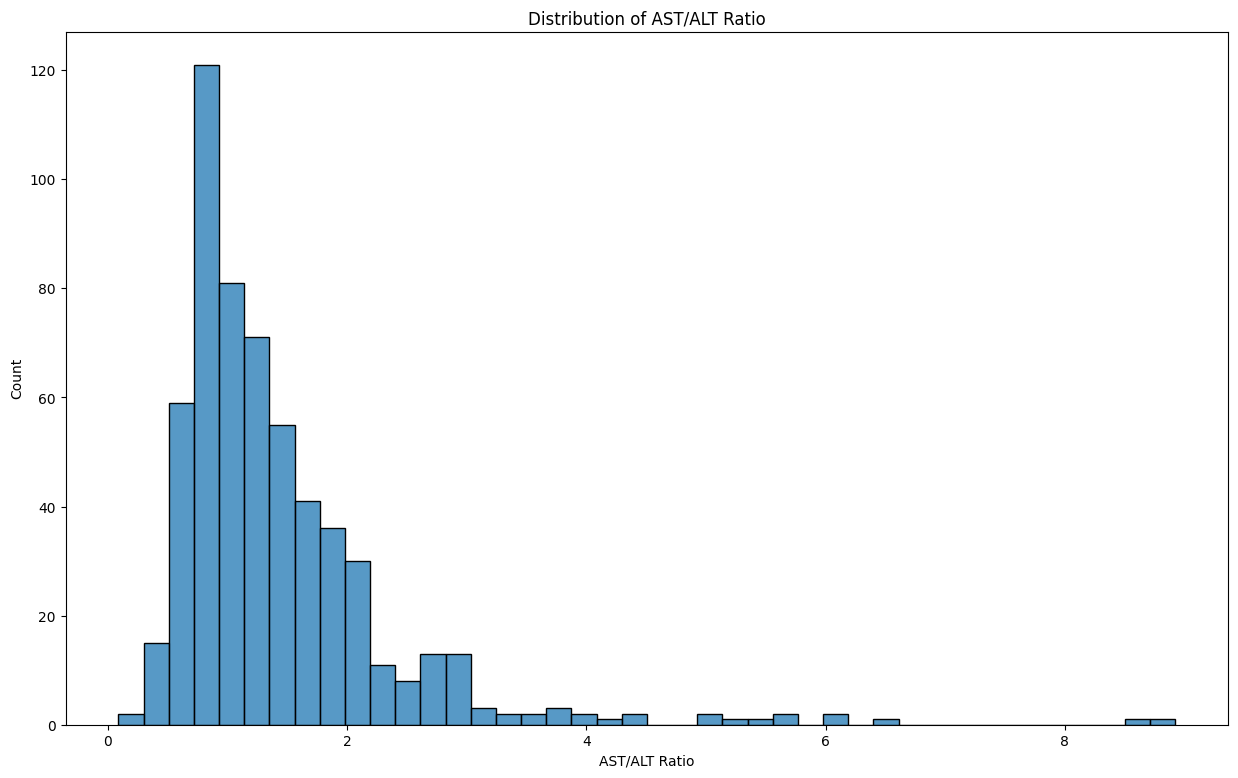

In [24]:
columns_to_visualize = ['Age','Total Bilirubin', 'Direct Bilirubin', 'ALP', 'ALT', 'AST', 'Total Proteins', 'Albumin', 'A/G Ratio', 'AST/ALT Ratio']

for column in columns_to_visualize:
    plt.figure(figsize=(15, 9))
    sns.histplot(x=df_liver[column])
    plt.title(f'Distribution of {column}')
    plt.show()

In [25]:
df_liver.describe()

,Age,Total Bilirubin,Direct Bilirubin,ALP,ALT,AST,Total Proteins,Albumin,A/G Ratio,AST/ALT Ratio
count,583.000000,583.000000,582.000000,579.000000,583.000000,582.000000,582.000000,583.000000,578.000000,582.000000
mean,44.746141,3.298799,1.488316,290.948187,80.713551,109.673540,6.484192,3.141852,0.946782,1.437045
std,16.189833,6.209522,2.810406,243.706658,182.620356,289.110208,1.086115,0.795519,0.319797,0.977908
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,0.089947
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,0.840000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.172671
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,1.724621
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,8.923077


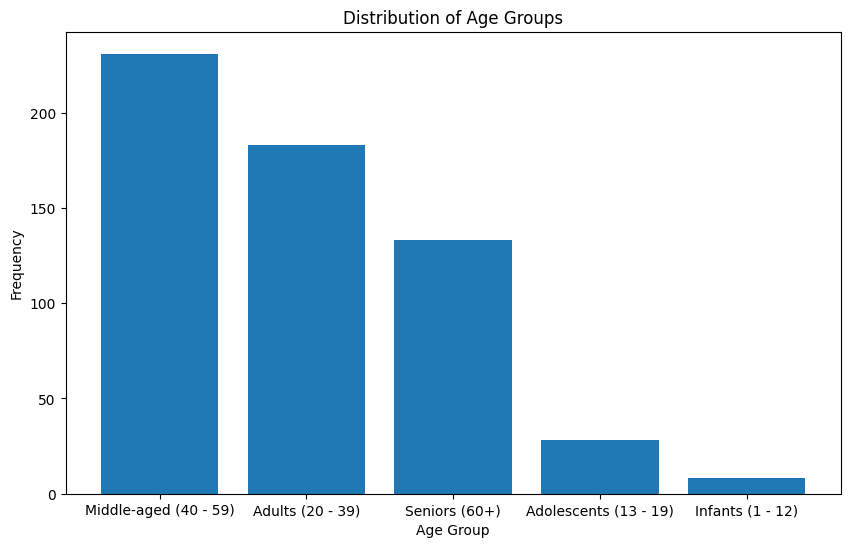

In [26]:
age_group_counts = df_liver['Age Group'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(age_group_counts.index, age_group_counts.values)

plt.xlabel('Age Group')
plt.ylabel('Frequency')
plt.title('Distribution of Age Groups')
plt.show()

# Categorization of Columns

In [27]:
categorized_data = {}

columns_to_categorize = ['Albumin', 'Total Bilirubin', 'Direct Bilirubin', 'ALP', 'ALT', 'AST', 'Total Proteins', 'A/G Ratio']

# Defining normal ranges for each column
normal_ranges = {
    'Total Bilirubin': (2.0, 17.0),
    'Direct Bilirubin': (0.0, 6.0),
    'ALP': (30, 120),
    'ALT': (4, 36),
    'AST': (5, 30),
    'Total Proteins': (6, 8),
    'Albumin': (3.5, 5.0),
    'A/G Ratio': (1.1, 2.5)
}

def categorize_value(value, normal_range):
    lower_bound, upper_bound = normal_range
    if lower_bound <= value <= upper_bound:
        return "Normal"
    elif value < lower_bound:
        return "Low"
    else:
        return "Elevated"

for column in columns_to_categorize:
    categorized_data[column] = df_liver[column].apply(lambda x: categorize_value(x, normal_ranges[column]))

df_categories = pd.DataFrame(categorized_data)

In [28]:
df_categories.head()

,Albumin,Total Bilirubin,Direct Bilirubin,ALP,ALT,AST,Total Proteins,A/G Ratio
0,Low,Low,Normal,Elevated,Normal,Normal,Normal,Low
1,Low,Normal,Normal,Elevated,Elevated,Elevated,Normal,Low
2,Low,Normal,Normal,Elevated,Elevated,Elevated,Normal,Low
3,Low,Low,Normal,Elevated,Normal,Normal,Normal,Low
4,Low,Normal,Normal,Elevated,Normal,Elevated,Normal,Low


In [29]:
table_data = {}

for column in df_categories.columns:
    category_counts = df_categories[column].value_counts()
    table_data[column] = category_counts

table_df = pd.DataFrame(table_data).T.fillna(0).astype(int)
table_df

,Elevated,Low,Normal
Albumin,2,372,209
Total Bilirubin,27,403,153
Direct Bilirubin,44,0,539
ALP,563,0,20
ALT,277,0,306
AST,379,0,204
Total Proteins,35,170,378
A/G Ratio,6,407,170


# Multivariate Analysis

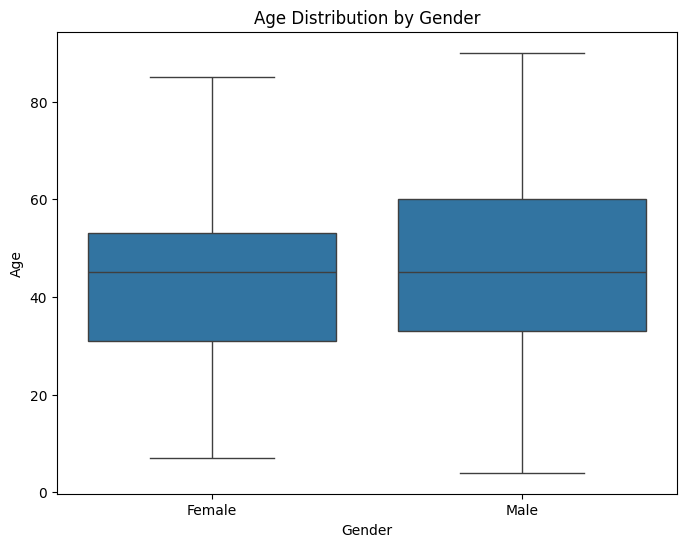

In [30]:
#correlation between age and gender
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Age', data=df_liver)
plt.title('Age Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()

In [31]:
df_liver['Gender'] = df_liver['Gender'].astype('category')
gender_numeric = df_liver['Gender'].cat.codes

correlation, p_value = stats.pointbiserialr(gender_numeric, df_liver['Age'])

print(f"Point-Biserial Correlation: {correlation}")
print(f"P-value: {p_value}")

Point-Biserial Correlation: 0.05656025132264456
P-value: 0.17262094615135412


:There is a weak positive correlation between age and gender and is statistically insignificant *(p-value=0.16(>0.05))*. This suggest that the observed difference in male and females is random.

# EDA QUESTIONS
Q1. What is the most affected age group?

Q2. What are the distributions of key variables?

Q3. What are the correlations between different liver function tests?

Q4. Are there any significant differences in liver function test results between male and female patients?

Q5. What are the summary statistics?


**Most affected age group**

In [32]:
mode_age_group

,Age Group
0,Middle-aged (40 - 59)


**Distributions of Key Variables**

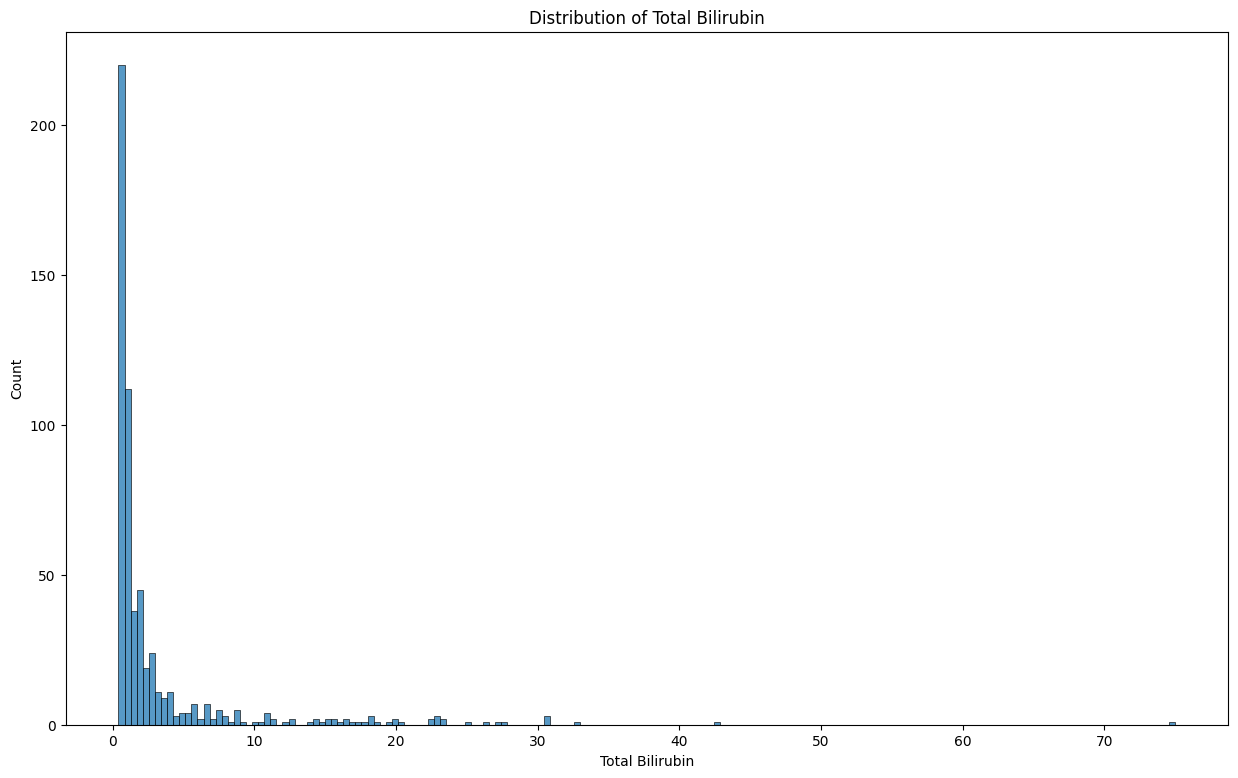

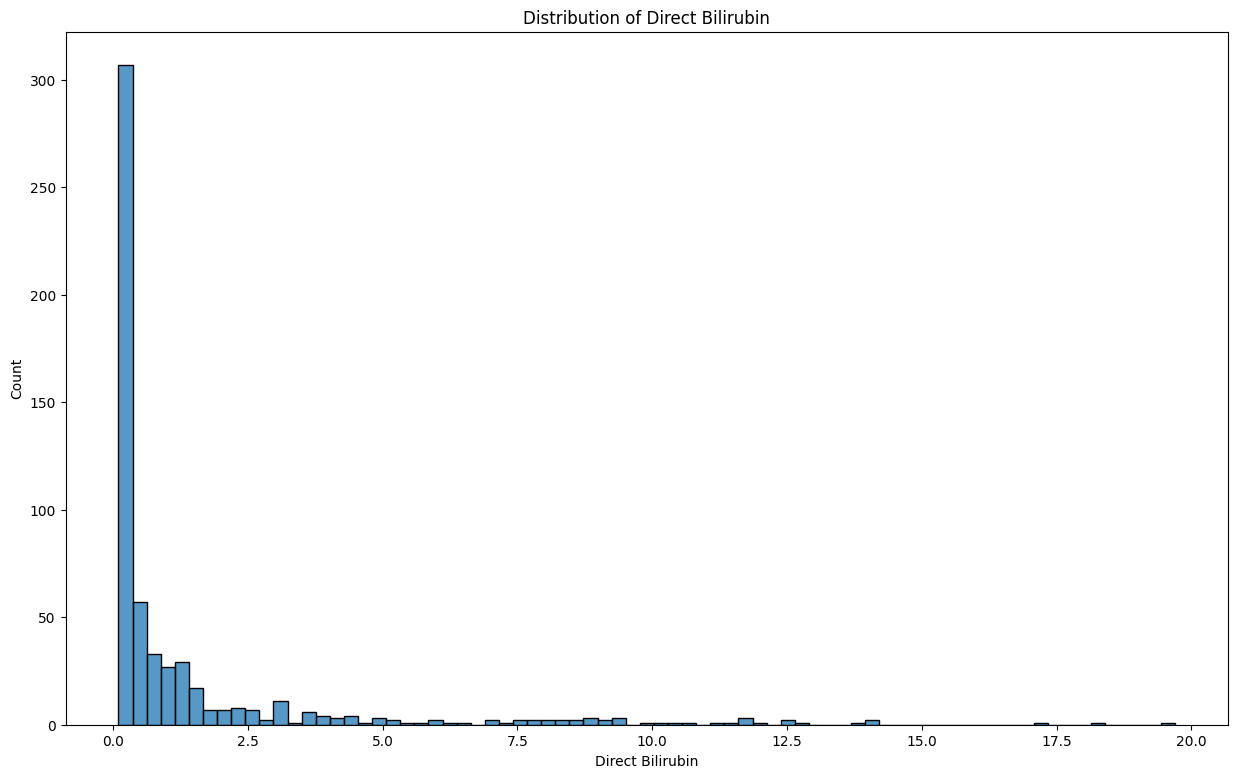

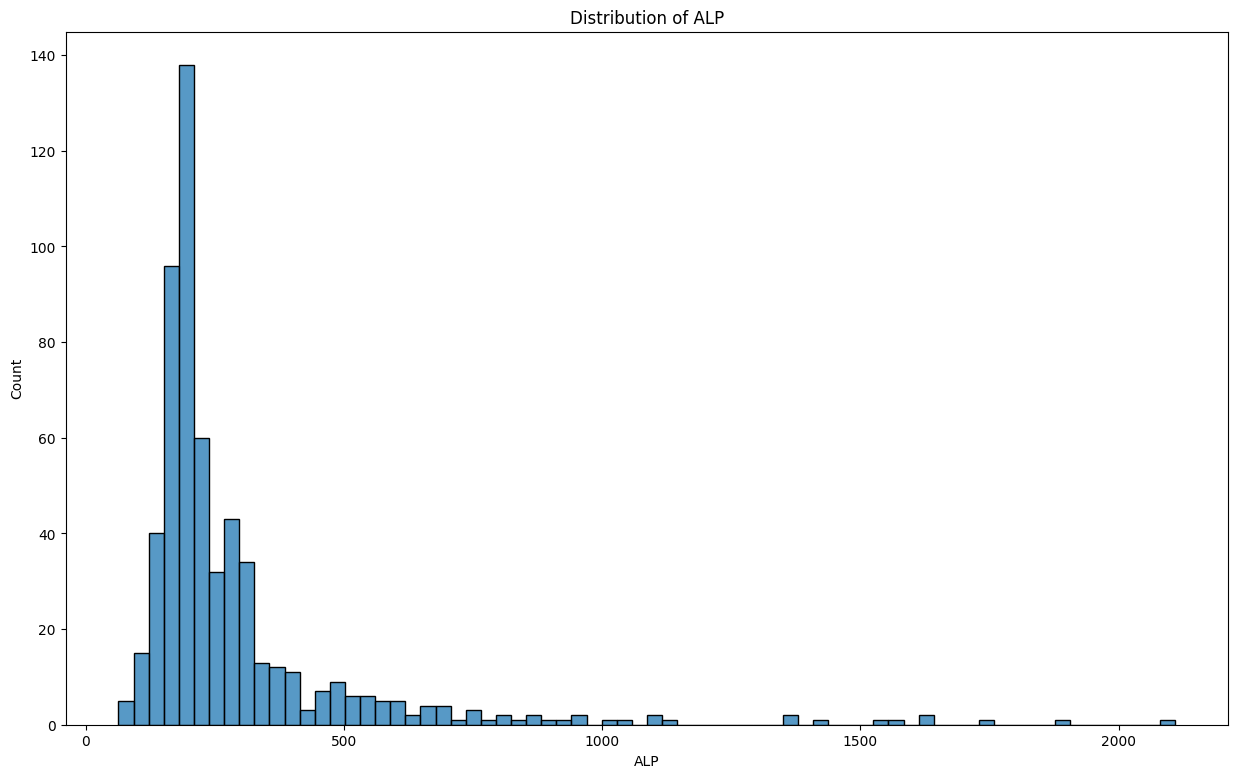

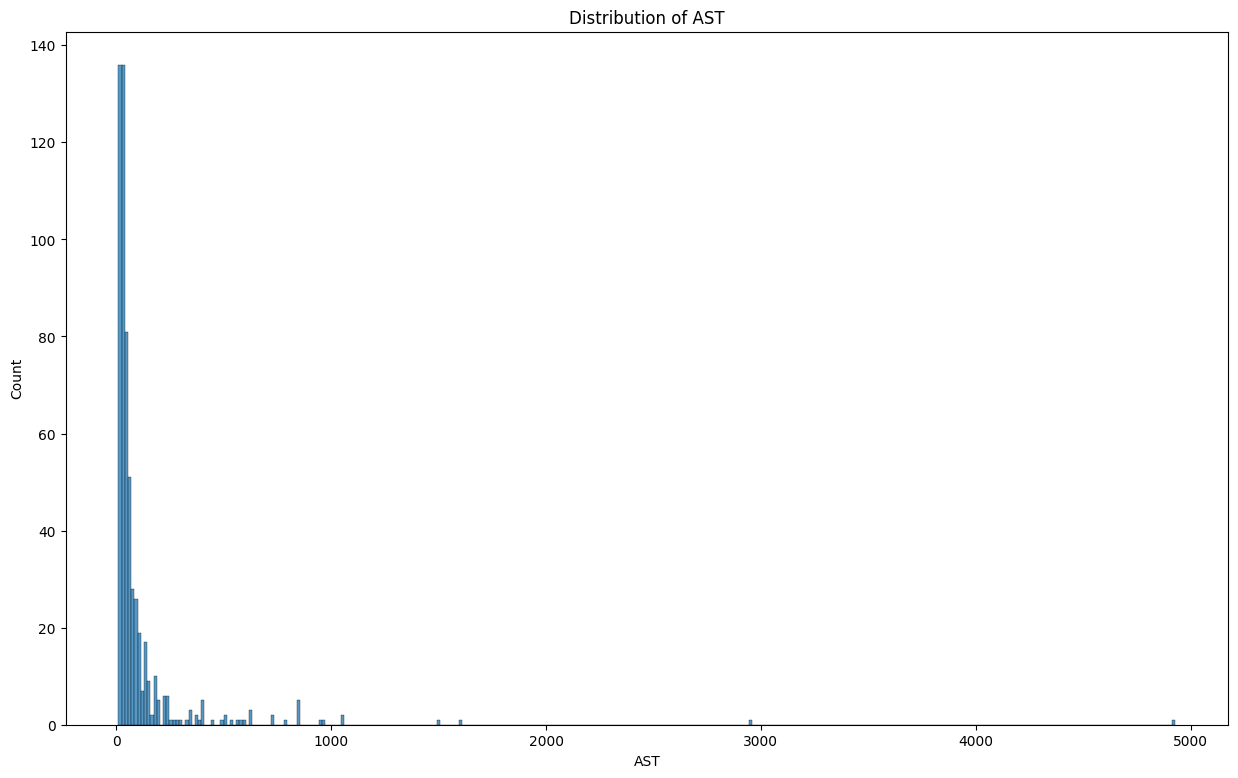

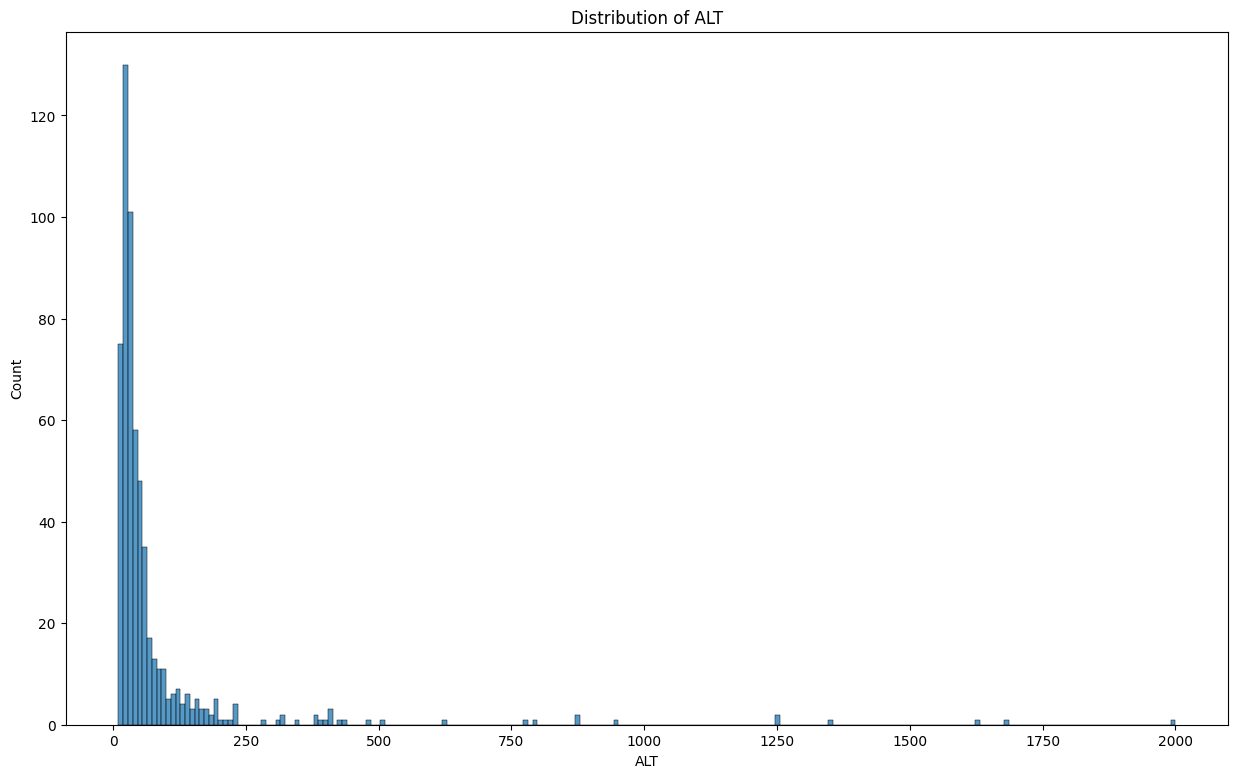

In [33]:
columns_to_visualize = ['Total Bilirubin', 'Direct Bilirubin', 'ALP', 'AST', 'ALT']

for column in columns_to_visualize:
    plt.figure(figsize=(15, 9))
    sns.histplot(x=df_liver[column])
    plt.title(f'Distribution of {column}')
    plt.show()

**Correlations between different liver function tests**

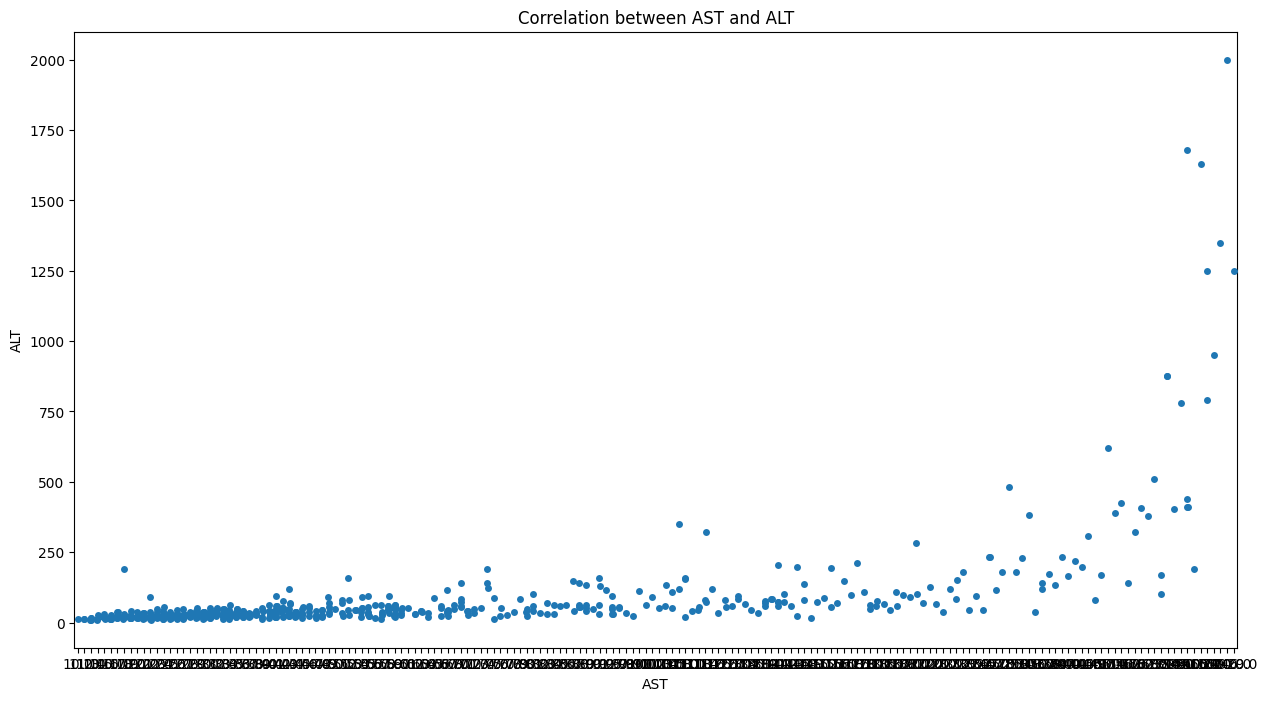

In [34]:
# AST and ALT Correlation
plt.figure(figsize=(15, 8))
sns.stripplot(x='AST', y='ALT', data=df_liver, jitter=True)

plt.title('Correlation between AST and ALT')
plt.show()

In [35]:
correlation, p_value = stats.pearsonr(df_liver['AST'], df_liver['ALT'])

print(f"Pearson Correlation: {correlation}")
print(f"P-value: {p_value}")

Pearson Correlation: nan
P-value: nan


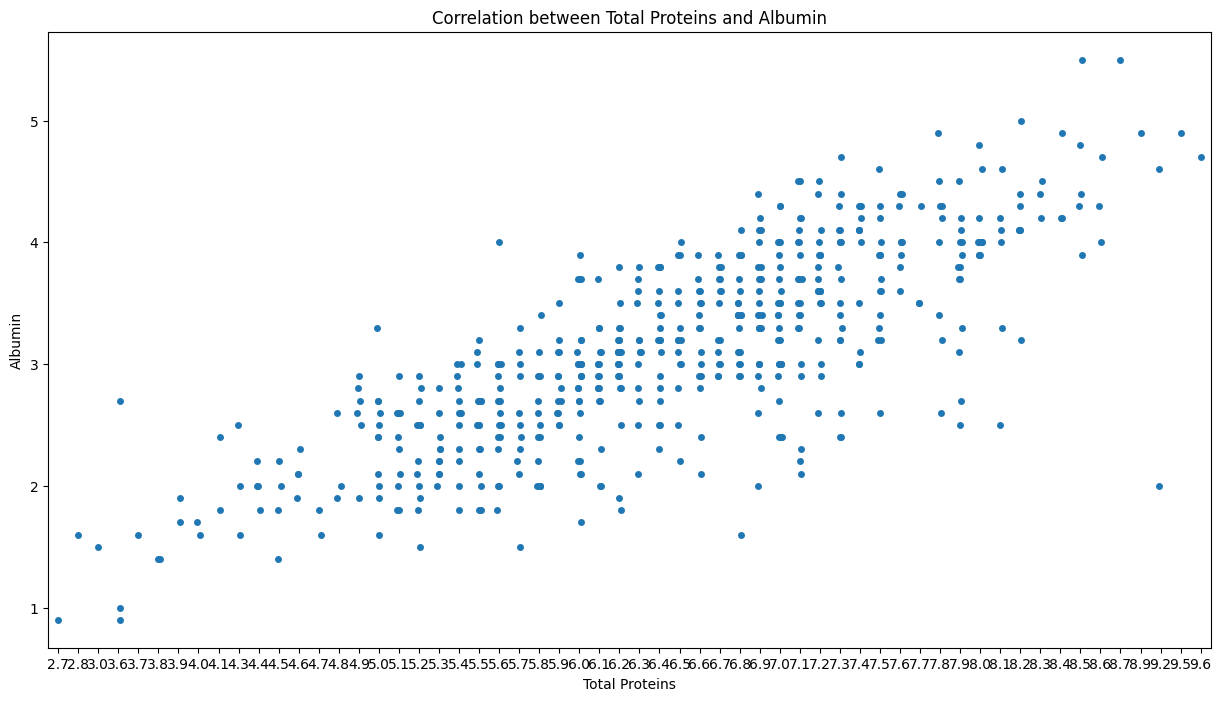

In [36]:
#Total Proteins and Albumin Correlation
plt.figure(figsize=(15, 8))
sns.stripplot(x='Total Proteins', y='Albumin', data=df_liver, jitter=True)

plt.title('Correlation between Total Proteins and Albumin')
plt.show()

In [37]:
correlation, p_value = stats.pearsonr(df_liver['Total Proteins'], df_liver['Albumin'])

print(f"Pearson Correlation: {correlation}")
print(f"P-value: {p_value}")

Pearson Correlation: nan
P-value: nan


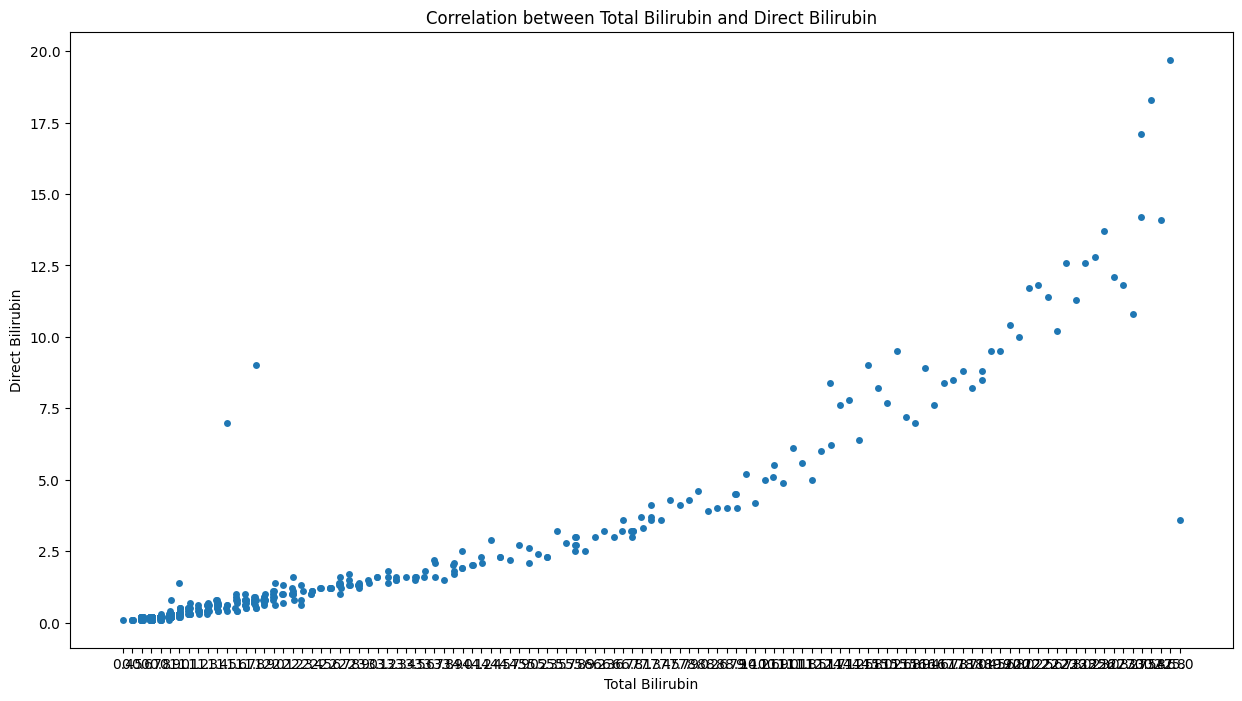

In [38]:
# Total Bilirubin and Direct Bilirubin Correlation
plt.figure(figsize=(15, 8))
sns.stripplot(x='Total Bilirubin', y='Direct Bilirubin', data=df_liver, jitter=True)

#Line of best fit
x = df_liver['Total Bilirubin']
y = df_liver['Direct Bilirubin']
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', label='Line of Best Fit')

plt.title('Correlation between Total Bilirubin and Direct Bilirubin')
plt.show()

In [39]:
correlation, p_value = stats.pearsonr(df_liver['Total Bilirubin'], df_liver['Direct Bilirubin'])

print(f"Pearson Correlation: {correlation}")
print(f"P-value: {p_value}")

Pearson Correlation: nan
P-value: nan


**Difference in Results between males and females**

In [40]:
#identifying specific patterns in liver function in males and females
gender_numeric = df_liver['Gender'].cat.codes

numeric_columns = df_liver.select_dtypes(include=['number', 'bool']).columns

for column in numeric_columns:
    if column != 'Gender':
        correlation, p_value = stats.pointbiserialr(gender_numeric, df_liver[column])
        print(f"Point-Biserial Correlation between Gender and {column}: {correlation}")
        print(f"P-value: {p_value}")

Point-Biserial Correlation between Gender and Age: 0.05656025132264456
P-value: 0.17262094615135412
Point-Biserial Correlation between Gender and Total Bilirubin: 0.08929082427172401
P-value: 0.03111161341039061
Point-Biserial Correlation between Gender and Direct Bilirubin: nan
P-value: nan
Point-Biserial Correlation between Gender and ALP: nan
P-value: nan
Point-Biserial Correlation between Gender and ALT: 0.08233223627321451
P-value: 0.046916613457444516
Point-Biserial Correlation between Gender and AST: nan
P-value: nan
Point-Biserial Correlation between Gender and Total Proteins: nan
P-value: nan
Point-Biserial Correlation between Gender and Albumin: -0.09379926625706468
P-value: 0.023515448264537938
Point-Biserial Correlation between Gender and A/G Ratio: nan
P-value: nan
Point-Biserial Correlation between Gender and AST/ALT Ratio: nan
P-value: nan


**Summary Statistics**

In [41]:
df_liver.describe()

,Age,Total Bilirubin,Direct Bilirubin,ALP,ALT,AST,Total Proteins,Albumin,A/G Ratio,AST/ALT Ratio
count,583.000000,583.000000,582.000000,579.000000,583.000000,582.000000,582.000000,583.000000,578.000000,582.000000
mean,44.746141,3.298799,1.488316,290.948187,80.713551,109.673540,6.484192,3.141852,0.946782,1.437045
std,16.189833,6.209522,2.810406,243.706658,182.620356,289.110208,1.086115,0.795519,0.319797,0.977908
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,0.089947
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,0.840000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.172671
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,1.724621
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,8.923077


In [42]:
df_liver.describe(include=['category'])

,Gender,Age Group
count,583,583
unique,2,5
top,Male,Middle-aged (40 - 59)
freq,441,231


In [43]:
'''from google.colab import files

df_liver.to_csv('liver_dataset.csv', index=False)
files.download('liver_dataset.csv')'''

"from google.colab import files\n\ndf_liver.to_csv('liver_dataset.csv', index=False)\nfiles.download('liver_dataset.csv')"